# 08. Embedding Separability Analysis

**Цель:** Измерить разделимость классов (safe vs jailbreak) на текущих эмбеддингах.

**Контекст:**
- Эмбеддер: `intfloat/multilingual-e5-large-instruct`
- Instruction-префикс НЕ используется
- Eval-сет: 210 adversarial_benign (safe) + 2000 adversarial_harmful (jailbreak)

**Вопрос:** Где узкое место — в эмбеддинге или в классификаторе?

In [1]:
import json
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.model_selection import StratifiedKFold, cross_val_predict
from sklearn.metrics import (
    roc_auc_score,
    balanced_accuracy_score,
    average_precision_score,
    silhouette_score,
    confusion_matrix,
)
from sklearn.metrics.pairwise import cosine_similarity
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt

warnings.filterwarnings('ignore')

# Paths
BASE = Path("..").resolve()
EVAL_EMB_PATH = BASE / "data/processed/embeddings_cache/intfloat_multilingual-e5-large-instruct_test.npy"
TRAIN_EMB_PATH = BASE / "data/processed/embeddings_cache/intfloat_multilingual-e5-large-instruct_full100k_seed42.npy"
EVAL_JSONL = BASE / "data/processed/wildjailbreak_eval_binary.jsonl"
TRAIN_JSON = BASE / "data/processed/wildjailbreak_full100k_seed42.json"
PIPELINE_RESULTS = BASE / "results/diagnostics/summary_table_full.csv"
OUTPUT_DIR = BASE / "results/diagnostics"

print(f"Eval embeddings: {EVAL_EMB_PATH}")
print(f"Train embeddings: {TRAIN_EMB_PATH}")

Eval embeddings: /Users/anastasiagapeeva/Documents/Education/AITH/ProjectPractice2/autoguardrails/tasks/jailbreak_detection/data/processed/embeddings_cache/intfloat_multilingual-e5-large-instruct_test.npy
Train embeddings: /Users/anastasiagapeeva/Documents/Education/AITH/ProjectPractice2/autoguardrails/tasks/jailbreak_detection/data/processed/embeddings_cache/intfloat_multilingual-e5-large-instruct_full100k_seed42.npy


## 1. Загрузка данных

In [2]:
# Load eval embeddings and labels
eval_emb = np.load(EVAL_EMB_PATH)

eval_labels = []
with open(EVAL_JSONL, "r", encoding="utf-8") as f:
    for line in f:
        eval_labels.append(json.loads(line)["label"])
eval_labels = np.array(eval_labels)

n_eval = len(eval_labels)
n_safe = sum(eval_labels == 0)
n_jailbreak = sum(eval_labels == 1)

print(f"Eval embeddings: {eval_emb.shape}")
print(f"Eval labels: {n_eval} (safe={n_safe}, jailbreak={n_jailbreak})")
print(f"Imbalance: 1:{n_jailbreak/n_safe:.1f}")

Eval embeddings: (2210, 1024)
Eval labels: 2210 (safe=210, jailbreak=2000)
Imbalance: 1:9.5


In [3]:
# Load train embeddings and labels
train_emb = np.load(TRAIN_EMB_PATH)

with open(TRAIN_JSON, "r", encoding="utf-8") as f:
    train_data = json.load(f)

# Extract labels: intents[0].utterances → 0, oos_utterances → 1
train_labels = []
for intent in train_data.get("intents", []):
    train_labels.extend([0] * len(intent.get("utterances", [])))
train_labels.extend([1] * len(train_data.get("oos_utterances", [])))
train_labels = np.array(train_labels)

print(f"Train embeddings: {train_emb.shape}")
print(f"Train labels: {len(train_labels)} (safe={sum(train_labels==0)}, jailbreak={sum(train_labels==1)})")

Train embeddings: (100000, 1024)
Train labels: 100000 (safe=50000, jailbreak=50000)


## 2. Геометрический анализ eval-сета

In [4]:
# Silhouette score
sil_score = silhouette_score(eval_emb, eval_labels, metric='cosine')

print("=== Silhouette Score ===")
print(f"Silhouette (cosine): {sil_score:.4f}")
print(f"\nИнтерпретация:")
if sil_score > 0.5:
    print("  Хорошая структура кластеров")
elif sil_score > 0.25:
    print("  Умеренная структура")
elif sil_score > 0:
    print("  СЛАБАЯ структура — кластеры сильно перекрываются")
else:
    print("  Нет структуры — кластеры смешаны")

=== Silhouette Score ===
Silhouette (cosine): 0.0882

Интерпретация:
  СЛАБАЯ структура — кластеры сильно перекрываются


In [5]:
# Cosine distances
safe_mask = eval_labels == 0
jailbreak_mask = eval_labels == 1

emb_safe = eval_emb[safe_mask]
emb_jailbreak = eval_emb[jailbreak_mask]

sim_within_safe = cosine_similarity(emb_safe)
sim_within_jailbreak = cosine_similarity(emb_jailbreak)
sim_between = cosine_similarity(emb_safe, emb_jailbreak)

triu_safe = np.triu_indices(len(emb_safe), k=1)
triu_jb = np.triu_indices(len(emb_jailbreak), k=1)

dist_within_safe = 1 - sim_within_safe[triu_safe]
dist_within_jailbreak = 1 - sim_within_jailbreak[triu_jb]
dist_between = 1 - sim_between.flatten()

print("=== Косинусные расстояния ===")
print(f"Внутри Safe:     {dist_within_safe.mean():.4f} ± {dist_within_safe.std():.4f}")
print(f"Внутри Jailbreak:{dist_within_jailbreak.mean():.4f} ± {dist_within_jailbreak.std():.4f}")
print(f"Между классами:  {dist_between.mean():.4f} ± {dist_between.std():.4f}")

avg_within = (dist_within_safe.mean() * len(dist_within_safe) + 
              dist_within_jailbreak.mean() * len(dist_within_jailbreak)) / \
             (len(dist_within_safe) + len(dist_within_jailbreak))
separation_ratio = dist_between.mean() / avg_within

print(f"\nSeparation ratio: {separation_ratio:.4f}")
print(f"Интерпретация: {'between > within (слабое разделение)' if separation_ratio > 1 else 'between ≤ within (нет разделения)'}")

=== Косинусные расстояния ===
Внутри Safe:     0.1912 ± 0.0345
Внутри Jailbreak:0.1747 ± 0.0349
Между классами:  0.1934 ± 0.0325

Separation ratio: 1.1058
Интерпретация: between > within (слабое разделение)


## 3. PCA-проекция

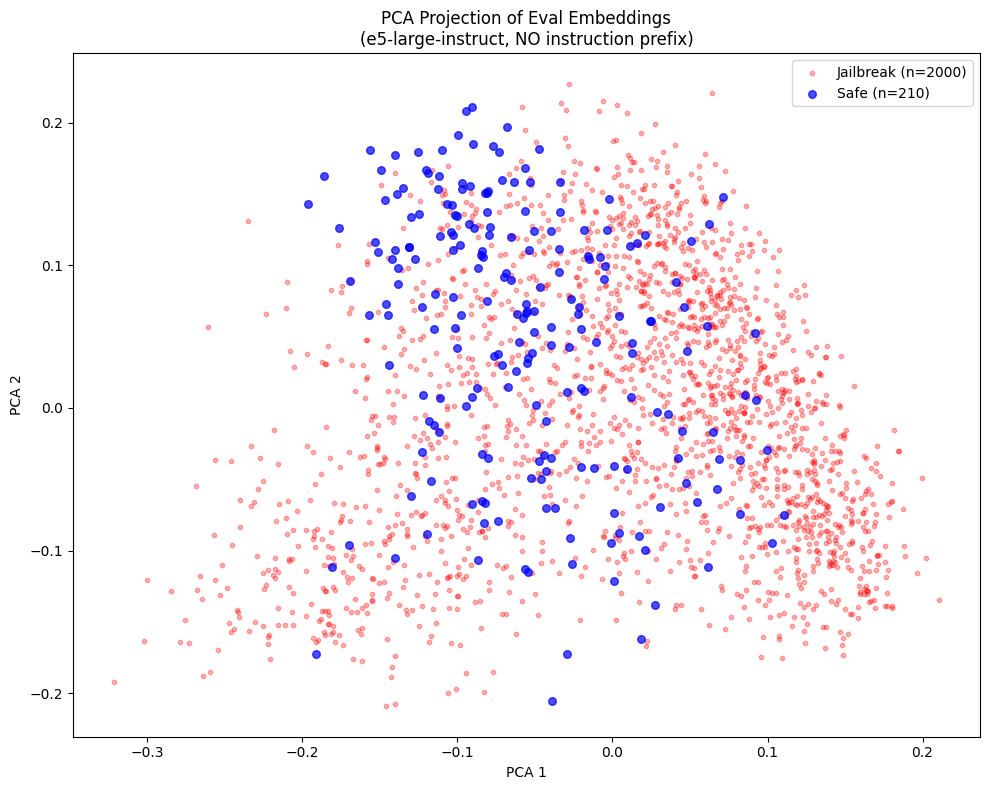

Классы ВИЗУАЛЬНО ПЕРЕКРЫВАЮТСЯ — safe распределены по всему jailbreak-облаку


In [6]:
# PCA projection
pca = PCA(n_components=2, random_state=42)
proj_emb = pca.fit_transform(eval_emb)

fig, ax = plt.subplots(figsize=(10, 8))

ax.scatter(
    proj_emb[jailbreak_mask, 0],
    proj_emb[jailbreak_mask, 1],
    c='red', alpha=0.3, s=10,
    label=f'Jailbreak (n={n_jailbreak})'
)
ax.scatter(
    proj_emb[safe_mask, 0],
    proj_emb[safe_mask, 1],
    c='blue', alpha=0.7, s=30,
    label=f'Safe (n={n_safe})'
)

ax.set_xlabel('PCA 1')
ax.set_ylabel('PCA 2')
ax.set_title('PCA Projection of Eval Embeddings\n(e5-large-instruct, NO instruction prefix)')
ax.legend(loc='best')

plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'umap_eval_no_prefix.png', dpi=150, bbox_inches='tight')
plt.show()

print(f"Классы ВИЗУАЛЬНО ПЕРЕКРЫВАЮТСЯ — safe распределены по всему jailbreak-облаку")

## 4. Probe: сравнение (train→eval)

**ВАЖНО:** Probe обучаем на TRAIN (100k), тестируем на EVAL (2210).
Это та же схема, что и у пайплайна.

In [8]:
# Train LogReg on train, evaluate on eval
lr = LogisticRegression(class_weight='balanced', max_iter=1000, random_state=42)
lr.fit(train_emb, train_labels)
eval_probs = lr.predict_proba(eval_emb)[:, 1]
eval_preds = (eval_probs >= 0.5).astype(int)

lr_roc = roc_auc_score(eval_labels, eval_probs)
lr_pr = average_precision_score(eval_labels, eval_probs)
lr_bal_acc = balanced_accuracy_score(eval_labels, eval_preds)

pr_baseline = n_jailbreak / n_eval

print("=== LogReg Probe (train→eval, balanced weights) ===")
print(f"ROC AUC: {lr_roc:.4f}")
print(f"PR AUC:  {lr_pr:.4f} (baseline={pr_baseline:.3f}, lift={lr_pr - pr_baseline:+.4f})")
print(f"Balanced Acc: {lr_bal_acc:.4f}")

=== LogReg Probe (train→eval, balanced weights) ===
ROC AUC: 0.7868
PR AUC:  0.9702 (baseline=0.905, lift=+0.0652)
Balanced Acc: 0.7123


In [9]:
# Score distributions
scores_safe = eval_probs[safe_mask]
scores_jb = eval_probs[jailbreak_mask]

print("=== Распределение скоров ===")
print(f"Safe:      mean={scores_safe.mean():.3f}, std={scores_safe.std():.3f}, range=[{scores_safe.min():.3f}, {scores_safe.max():.3f}]")
print(f"Jailbreak: mean={scores_jb.mean():.3f}, std={scores_jb.std():.3f}, range=[{scores_jb.min():.3f}, {scores_jb.max():.3f}]")
print(f"\nGap между средними: {scores_jb.mean() - scores_safe.mean():.3f}")
print(f"Диапазоны ПЕРЕКРЫВАЮТСЯ — отсюда ошибки классификации")

=== Распределение скоров ===
Safe:      mean=0.404, std=0.285, range=[0.006, 0.985]
Jailbreak: mean=0.715, std=0.269, range=[0.008, 1.000]

Gap между средними: 0.311
Диапазоны ПЕРЕКРЫВАЮТСЯ — отсюда ошибки классификации


In [10]:
# Confusion matrix
cm = confusion_matrix(eval_labels, eval_preds)
tn, fp, fn, tp = cm.ravel()

print("=== Confusion Matrix (threshold=0.5) ===")
print(f"                 Predicted")
print(f"                 Safe    Jailbreak")
print(f"Actual Safe      {tn:5d}    {fp:5d}")
print(f"Actual Jailbreak {fn:5d}    {tp:5d}")

tpr = tp / (tp + fn)
over_refusal = fp / n_safe

print(f"\nJailbreak Recall: {tpr:.3f}")
print(f"Over-refusal: {over_refusal:.3f} ({fp}/{n_safe} safe помечены как jailbreak)")

=== Confusion Matrix (threshold=0.5) ===
                 Predicted
                 Safe    Jailbreak
Actual Safe        138       72
Actual Jailbreak   465     1535

Jailbreak Recall: 0.767
Over-refusal: 0.343 (72/210 safe помечены как jailbreak)


## 5. Сравнение с пайплайном

In [11]:
# Load pipeline results
pipeline_df = pd.read_csv(PIPELINE_RESULTS)
print("Pipeline results (full runs):")
print(pipeline_df[['seed', 'roc_auc', 'pr_auc']].to_string(index=False))

pipeline_roc_mean = pipeline_df['roc_auc'].mean()

Pipeline results (full runs):
 seed  roc_auc   pr_auc
   42 0.740345 0.955415
  123 0.740817 0.955951
  456 0.791533 0.970668


In [12]:
# Comparison
diff = lr_roc - pipeline_roc_mean

print("\n=== Сравнение ===")
print(f"LogReg probe (train→eval): {lr_roc:.4f}")
print(f"Pipeline (full, mean):     {pipeline_roc_mean:.4f}")
print(f"Разница:                   {diff:+.4f}")

print(f"\nПайплайн достигает {100*pipeline_roc_mean/lr_roc:.0f}% от потолка эмбеддингов")


=== Сравнение ===
LogReg probe (train→eval): 0.7868
Pipeline (full, mean):     0.7576
Разница:                   +0.0293

Пайплайн достигает 96% от потолка эмбеддингов


In [13]:
# Verdict
THRESHOLD = 0.05

if diff > THRESHOLD:
    verdict = "PROBE_ABOVE"
    interpretation = "Пайплайн теряет сигнал — bottleneck в scoring/decision"
elif diff < -THRESHOLD:
    verdict = "PROBE_BELOW"
    interpretation = "Пайплайн лучше простого probe"
else:
    verdict = "PROBE_SAME"
    interpretation = "Пайплайн близок к потолку — bottleneck в ЭМБЕДДИНГЕ"

print(f"\n=== ВЕРДИКТ: {verdict} ===")
print(interpretation)


=== ВЕРДИКТ: PROBE_SAME ===
Пайплайн близок к потолку — bottleneck в ЭМБЕДДИНГЕ


## 6. Итоговый вывод

In [14]:
print("="*60)
print("ИТОГОВЫЙ ВЫВОД")
print("="*60)

print(f"\nГеометрия:")
print(f"  Silhouette Score:   {sil_score:.3f} (слабая структура)")
print(f"  Separation Ratio:   {separation_ratio:.3f} (between ≈ within)")
print(f"  PCA-проекция:       классы визуально перекрываются")

print(f"\nПроизводительность:")
print(f"  Probe ROC AUC:      {lr_roc:.4f}")
print(f"  Pipeline ROC AUC:   {pipeline_roc_mean:.4f}")
print(f"  Разница:            {diff:+.4f} ({100*diff/lr_roc:.1f}%)")

print(f"\n→ Вердикт: {verdict}")
print(f"→ {interpretation}")

if verdict == "PROBE_SAME":
    print(f"\n*** УЗКОЕ МЕСТО — ЭМБЕДДИНГ ***")
    print(f"Классы слабо разделимы в embedding space.")
    print(f"Направления: instruction prefix, fine-tune, другой эмбеддер.")

print(f"\n⚠️  ВАЖНО: probe здесь ЛИНЕЙНЫЙ (LogReg)")
print(f"   → меряет ЛИНЕЙНЫЙ потолок, не потолок фич")
print(f"   → см. notebook 09 для нелинейного probe и уточнения вывода")

ИТОГОВЫЙ ВЫВОД

Геометрия:
  Silhouette Score:   0.088 (слабая структура)
  Separation Ratio:   1.106 (between ≈ within)
  PCA-проекция:       классы визуально перекрываются

Производительность:
  Probe ROC AUC:      0.7868
  Pipeline ROC AUC:   0.7576
  Разница:            +0.0293 (3.7%)

→ Вердикт: PROBE_SAME
→ Пайплайн близок к потолку — bottleneck в ЭМБЕДДИНГЕ

*** УЗКОЕ МЕСТО — ЭМБЕДДИНГ ***
Классы слабо разделимы в embedding space.
Направления: instruction prefix, fine-tune, другой эмбеддер.

⚠️  ВАЖНО: probe здесь ЛИНЕЙНЫЙ (LogReg)
   → меряет ЛИНЕЙНЫЙ потолок, не потолок фич
   → см. notebook 09 для нелинейного probe и уточнения вывода


In [15]:
# Save summary
summary = {
    'geometric_analysis': {
        'silhouette_score': float(sil_score),
        'separation_ratio': float(separation_ratio),
    },
    'probe_train_to_eval': {
        'roc_auc': float(lr_roc),
        'pr_auc': float(lr_pr),
    },
    'pipeline_comparison': {
        'pipeline_roc_mean': float(pipeline_roc_mean),
        'difference': float(diff),
        'verdict': verdict,
    }
}

with open(OUTPUT_DIR / 'embedding_separability_summary.json', 'w') as f:
    json.dump(summary, f, indent=2)

print(f"Saved: {OUTPUT_DIR / 'embedding_separability_summary.json'}")

Saved: /Users/anastasiagapeeva/Documents/Education/AITH/ProjectPractice2/autoguardrails/tasks/jailbreak_detection/results/diagnostics/embedding_separability_summary.json
